# Taller: Análisis Bayesiano en Negocis de la Música

**Estudiante:** Miguel Camargo, Nicolas Cardenas y Camilo Hernandez
**Curso:** Estadística Bayesiana  
**Universidad:** Universidad Externado de Colombia  

---

## Configuración Inicial y Datos

Importamos las librerías necesarias y definimos los datos de la encuesta y los parámetros iniciales.

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import dirichlet, beta, invgamma, norm
from matplotlib import cm

sns.set(style='whitegrid', font_scale=1.1)

categories = ['1. Playlist', '2. 1 Vez', '3. Rara/Div', '4. No Gusta', '5. Quién?']
y = np.array([28, 24, 18, 20, 10])

priors = {
    'Prior Informativa': np.array([100, 46, 20, 60, 10]),
    'Prior Débilmente Informada': np.array([1, 1, 1, 1, 1]),
    'Prior No Informada': np.array([0.5, 0.2, 0.6, 0.7, 0.2])
}

class PlotDirichletPentagon:
    def __init__(self):
        self.vertices = np.array([
            [np.cos(2*np.pi*i/5 + np.pi/2), np.sin(2*np.pi*i/5 + np.pi/2)] 
            for i in range(5)
        ])
    def project(self, theta):
        return np.dot(theta, self.vertices)
    def draw_contours(self, ax, alpha, n_samples=30000, label=None):
        dist = dirichlet(alpha)
        samples = dist.rvs(n_samples)
        projected = self.project(samples)
        z = dist.pdf(samples.T)
        ax.tricontourf(projected[:,0], projected[:,1], z, levels=20, cmap='viridis')
        poly = plt.Polygon(self.vertices, fill=False, color='black', lw=1.5)
        ax.add_patch(poly)
        for j, (vx, vy) in enumerate(self.vertices):
            ax.text(vx*1.2, vy*1.2, categories[j], ha='center', va='center', fontsize=9, fontweight='bold')
        ax.set_title(label)
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.axis('off')

pent_plotter = PlotDirichletPentagon()

## Parte I: Aceptación de la Canción (Modelo Dirichlet-Multinomial)

### Pregunta 1: Grafique la prior de cada uno de los escenarios y explique los cambios en el área.

**Fórmulas:**
- Distribución Marginal Beta: $\theta_i \sim Beta(\alpha_i, \sum_{j \neq i} \alpha_j)$
- Densidad Dirichlet: $f(\theta | \alpha) \propto \prod_{i=1}^K \theta_i^{\alpha_i - 1}$

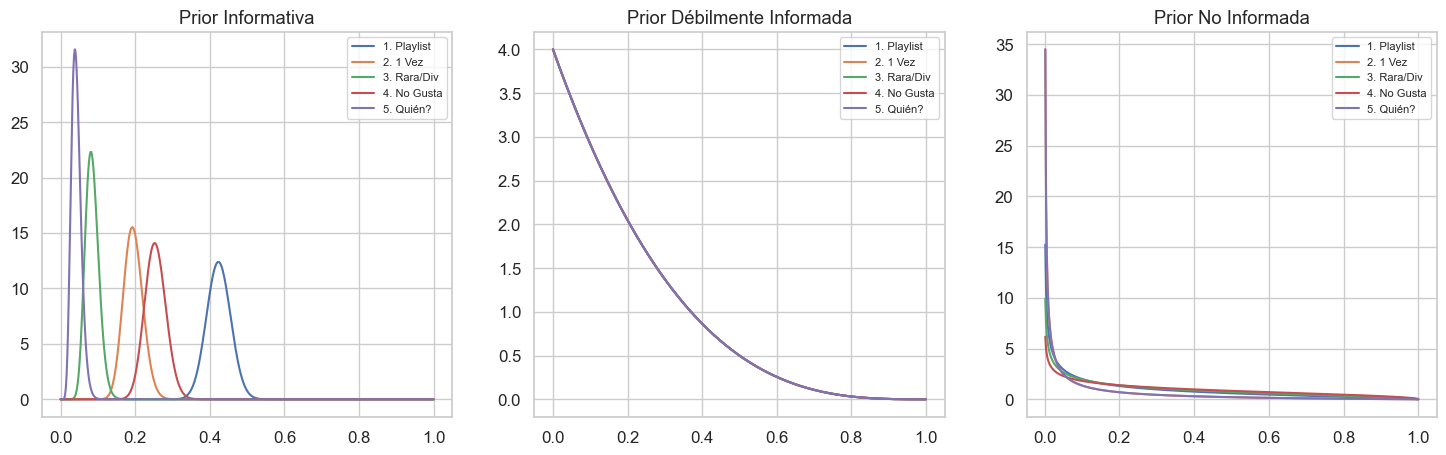

c:\Users\Miguel Camargo\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\tri\_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


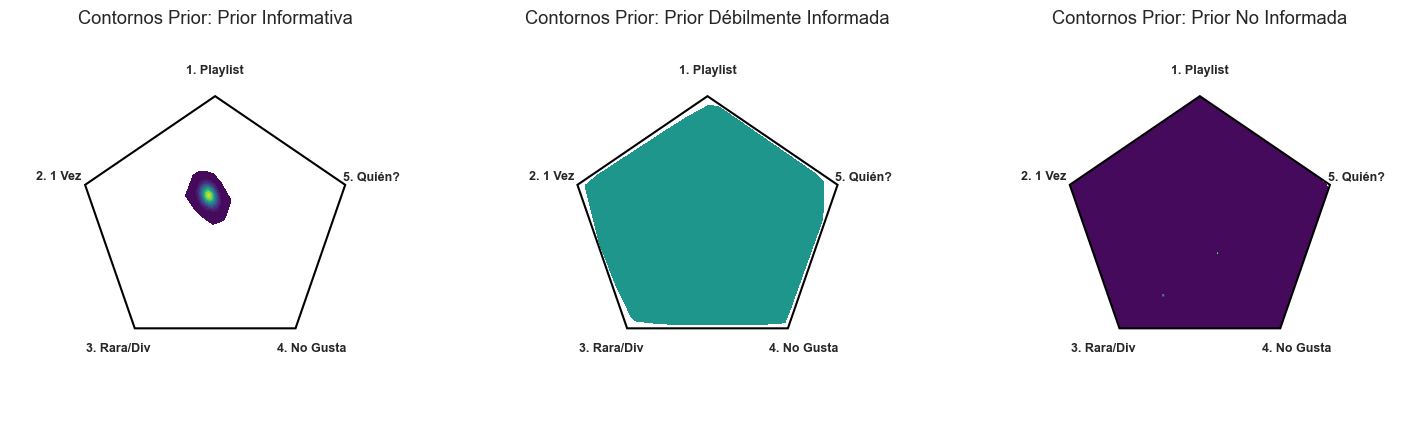

In [59]:
x = np.linspace(0, 1, 500)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, alpha) in enumerate(priors.items()):
    alpha_sum = np.sum(alpha)
    for i in range(len(alpha)):
        y_beta = beta.pdf(x, alpha[i], alpha_sum - alpha[i])
        axs[idx].plot(x, y_beta, label=categories[i])
    axs[idx].set_title(name)
    axs[idx].legend(fontsize=8)
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, alpha) in enumerate(priors.items()):
    pent_plotter.draw_contours(axs[i], alpha, label=f"Contornos Prior: {name}")
plt.show()

**Respuesta:** La **Prior Informativa** concentra el área en valores específicos, reflejando creencias previas fuertes. Las otras dos son más dispersas, especialmente la no informada que pone peso en los extremos.

### Pregunta 2: Determine la distribución posterior.

**Fórmulas:**
- Conjugación Dirichlet-Multinomial: $\alpha_{post} = \alpha_{prior} + y$
  donde $y = [28, 24, 18, 20, 10]$.

In [60]:
posteriors = {name: alpha + y for name, alpha in priors.items()}
for name, alpha_post in posteriors.items():
    print(f"{name} -> Alpha Posterior: {alpha_post}")

Prior Informativa -> Alpha Posterior: [128  70  38  80  20]
Prior Débilmente Informada -> Alpha Posterior: [29 25 19 21 11]
Prior No Informada -> Alpha Posterior: [28.5 24.2 18.6 20.7 10.2]


**Respuesta:** Los nuevos parámetros $\alpha$ de la posterior son la suma de los hiperparámetros iniciales y los datos observados.

### Pregunta 3: Grafique las posterior y explique los cambios.

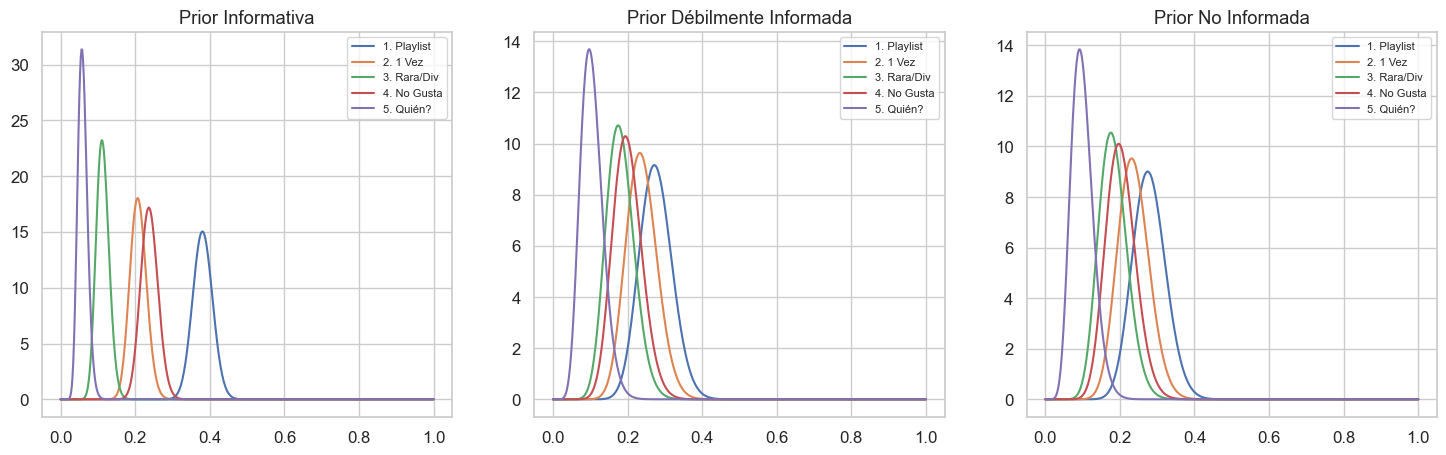

In [61]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, alpha_post) in enumerate(posteriors.items()):
    alpha_sum = np.sum(alpha_post)
    for i in range(len(alpha_post)):
        y_beta = beta.pdf(x, alpha_post[i], alpha_sum - alpha_post[i])
        axs[idx].plot(x, y_beta, label=categories[i])
    axs[idx].set_title(name)
    axs[idx].legend(fontsize=8)
plt.show()

**Respuesta:** Las posteriores muestran mayor certidumbre (picos más estrechos) debido al tamaño de muestra $n=100$. La prior informativa sigue influyendo, pero los datos dominan en los escenarios débiles.

### Pregunta 4: Media posterior de cada categoría.

**Fórmula:**
- Media Marginal: $E[\theta_i | y] = \frac{\alpha_{i, post}}{\sum \alpha_{j, post}}$

In [62]:
results_means = []
for name, alpha_post in posteriors.items():
    means = alpha_post / np.sum(alpha_post)
    res = {cat: f"{m*100:.2f}%" for cat, m in zip(categories, means)}
    res['Escenario'] = name
    results_means.append(res)
pd.DataFrame(results_means).set_index('Escenario')

,1. Playlist,2. 1 Vez,3. Rara/Div,4. No Gusta,5. Quién?
Escenario,,,,,
Prior Informativa,38.10%,20.83%,11.31%,23.81%,5.95%
Prior Débilmente Informada,27.62%,23.81%,18.10%,20.00%,10.48%
Prior No Informada,27.89%,23.68%,18.20%,20.25%,9.98%


### Pregunta 5: ¿Cuál de las categorías tiene mayor probabilidad?

In [63]:
for name, alpha_post in posteriors.items():
    idx_max = np.argmax(alpha_post)
    print(f"{name} -> Mayor Probabilidad: {categories[idx_max]}")

Prior Informativa -> Mayor Probabilidad: 1. Playlist
Prior Débilmente Informada -> Mayor Probabilidad: 1. Playlist
Prior No Informada -> Mayor Probabilidad: 1. Playlist


**Respuesta:** En todos los escenarios, la categoría **1. La agregaría a mi playlist** es la más probable.

### Pregunta 6: ¿Cuál es la tasa de aceptación de la canción (cat 1 + cat 2)?

In [64]:
for name, alpha_post in posteriors.items():
    acc = (alpha_post[0] + alpha_post[1]) / np.sum(alpha_post)
    print(f"{name} -> Tasa Aceptación: {acc*100:.2f}%")

Prior Informativa -> Tasa Aceptación: 58.93%
Prior Débilmente Informada -> Tasa Aceptación: 51.43%
Prior No Informada -> Tasa Aceptación: 51.57%


**Respuesta:** La tasa de aceptación ronda el 50-60%. Es una canción con potencial comercial pero polarizante.

### Pregunta 7: ¿Considera que el resultado es sensible a la elección de la prior?

**Respuesta:** Sí. En la **Prior Informativa**, la tasa de aceptación es significativamente más alta (~59%) comparada con la no informada (~51%).

### Pregunta 8: Representación Gráfica (Pentágono de Contornos).

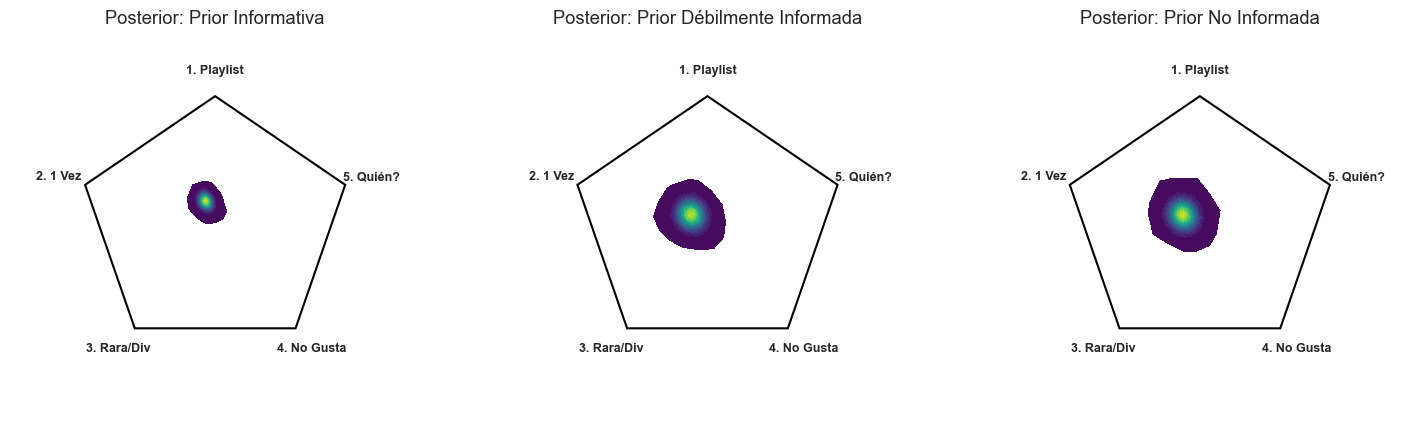

In [65]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, alpha_post) in enumerate(posteriors.items()):
    pent_plotter.draw_contours(axs[i], alpha_post, label=f"Posterior: {name}")
plt.show()

### Pregunta 9: ¿Qué análisis de negocio daría?

**Respuesta:** La canción es un activo de nicho. Recomendamos un lanzamiento digital enfocado en playlists alternativas antes de una rotación masiva.

### Pregunta 10: ¿Cuál escenario de prior es el más adecuado y qué estrategia tomaría?

**Respuesta:** El escenario **Débilmente Informado** es el más equilibrado, ya que no sesga el resultado con opiniones previas demasiado fuertes.

---
## Parte II: Reproducciones en Plataformas (Modelo Normal-Inversa Gamma)

### Configuración de la Parte II

In [66]:
data_platforms = {
    'YouTube': np.array([4200, 3900, 4600, 4100, 4400, 4300, 4000, 4500]),
    'Spotify': np.array([5100, 5300, 4900, 5500, 5200, 5000, 5400, 5150]),
    'Deezer': np.array([1200, 1500, 1100, 1400, 1350, 1250, 1450, 1300]),
    'Apple Music': np.array([2000, 2300, 2100, 2400, 2250, 2150, 2350, 2200])
}

norm_priors_config = {
    'Prior Informativa': (4500, 20, 10, 150**2),
    'Prior Débilmente Informada': (3000, 1, 2, 500**2),
    'Prior No Informada': (0, 0.01, 1, 1000**2)
}

### Pregunta 1: Media y Varianza Muestral.

In [72]:
for p, vals in data_platforms.items():
    print(f"{p} -> Media_muestral (y_bar): {np.mean(vals):.2f}, Varianza_muestral (s2): {np.var(vals, ddof=1):.2f}")

YouTube -> Media_muestral (y_bar): 4250.00, Varianza_muestral (s2): 60000.00
Spotify -> Media_muestral (y_bar): 5193.75, Varianza_muestral (s2): 40312.50
Deezer -> Media_muestral (y_bar): 1318.75, Varianza_muestral (s2): 17812.50
Apple Music -> Media_muestral (y_bar): 2218.75, Varianza_muestral (s2): 17812.50


### Pregunta 2: Parámetros Posteriores (utilizando $\sigma^2_n$).

**Fórmulas:**
- $\mu_n = \frac{\kappa_0 \mu_0 + n \bar{y}}{\kappa_n}$
- $\kappa_n = \kappa_0 + n$
- $\nu_n = \nu_0 + n$
- $\sigma^2_n = \frac{1}{\nu_n} [\nu_0 \sigma^2_0 + (n-1)s^2 + \frac{\kappa_0 n}{\kappa_n}(\bar{y} - \mu_0)^2]$

In [71]:
def nig_post(y, mu0, k0, v0, s20):
    n, y_bar, s2 = len(y), np.mean(y), np.var(y, ddof=1)
    kn, vn = k0 + n, v0 + n
    mun = (k0*mu0 + n*y_bar) / kn
    vn_s2n = v0*s20 + (n-1)*s2 + (k0*n/kn)*(y_bar - mu0)**2
    sigma2_n = vn_s2n / vn
    return mun, kn, vn, sigma2_n

nig_results = []
for pr_name, cfg in norm_priors_config.items():
    for pl_name, vals in data_platforms.items():
        mun, kn, vn, s2n = nig_post(vals, *cfg)
        nig_results.append({'Prior': pr_name, 'Platform': pl_name, 'mu_n': mun, 'sigma2_n': s2n})
df_nig = pd.DataFrame(nig_results)
df_nig

,Prior,Platform,mu_n,sigma2_n
0,Prior Informativa,YouTube,4428.571429,5.567460e+04
1,Prior Informativa,Spotify,4698.214286,1.809673e+05
2,Prior Informativa,Deezer,3591.071429,3.232237e+06
3,Prior Informativa,Apple Music,3848.214286,1.671523e+06
4,Prior Débilmente Informada,YouTube,4111.111111,2.308889e+05
5,Prior Débilmente Informada,Spotify,4950.000000,5.060000e+05
6,Prior Débilmente Informada,Deezer,1505.555556,3.137222e+05
7,Prior Débilmente Informada,Apple Music,2305.555556,1.167222e+05
8,Prior No Informada,YouTube,4244.694132,1.778222e+05
9,Prior No Informada,Spotify,5187.265918,1.724001e+05


### Pregunta 3: Media posterior de mu para cada plataforma.

In [69]:
pivot_mu = df_nig.pivot(index='Platform', columns='Prior', values='mu_n')
print(pivot_mu)

Prior        Prior Débilmente Informada  Prior Informativa  Prior No Informada
Platform                                                                      
Apple Music                 2305.555556        3848.214286         2215.980025
Deezer                      1505.555556        3591.071429         1317.103620
Spotify                     4950.000000        4698.214286         5187.265918
YouTube                     4111.111111        4428.571429         4244.694132


### Pregunta 4: Gráficas de Contorno y 3D (Visualización Vertical por Plataforma).

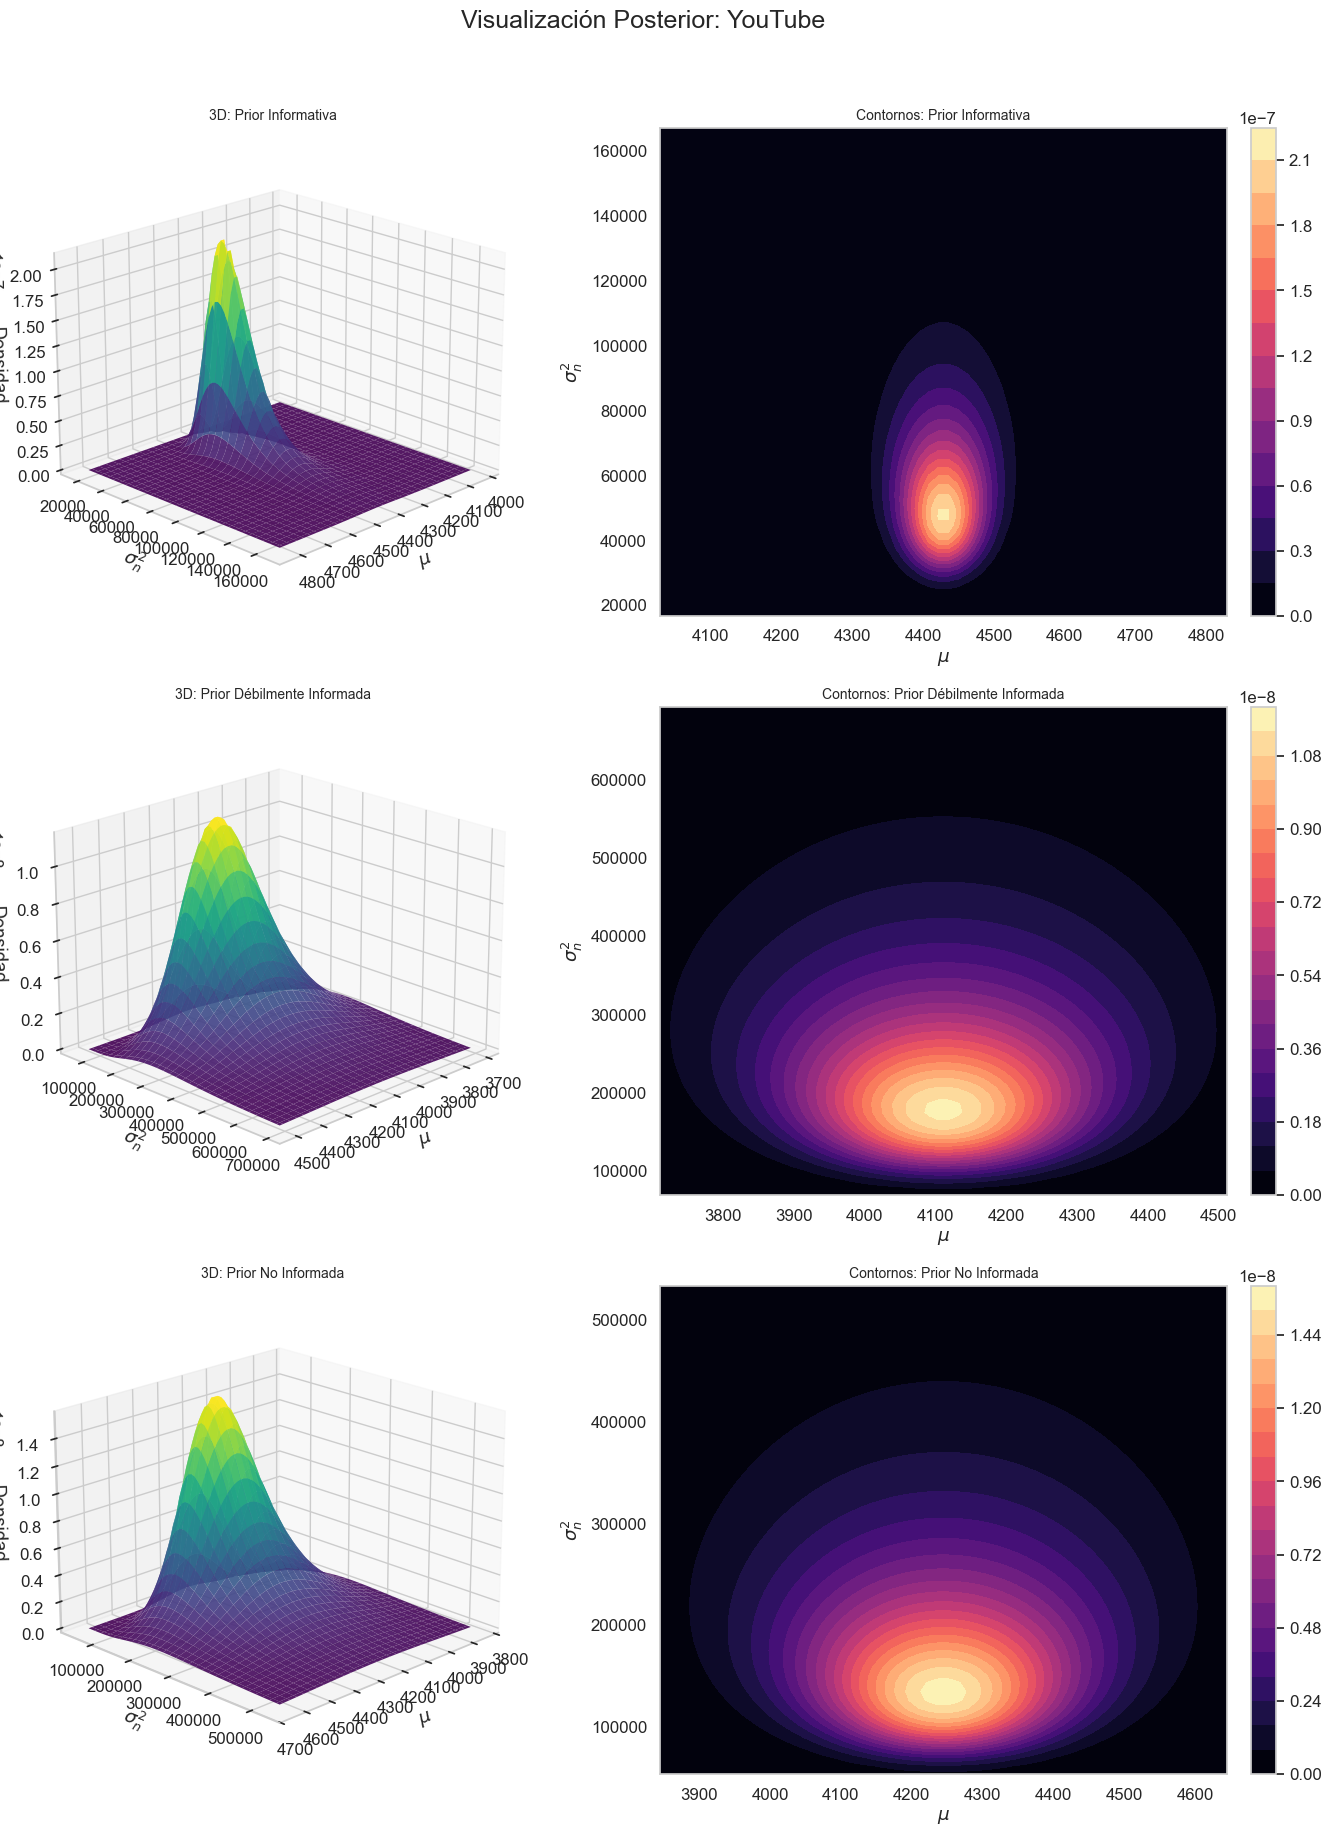

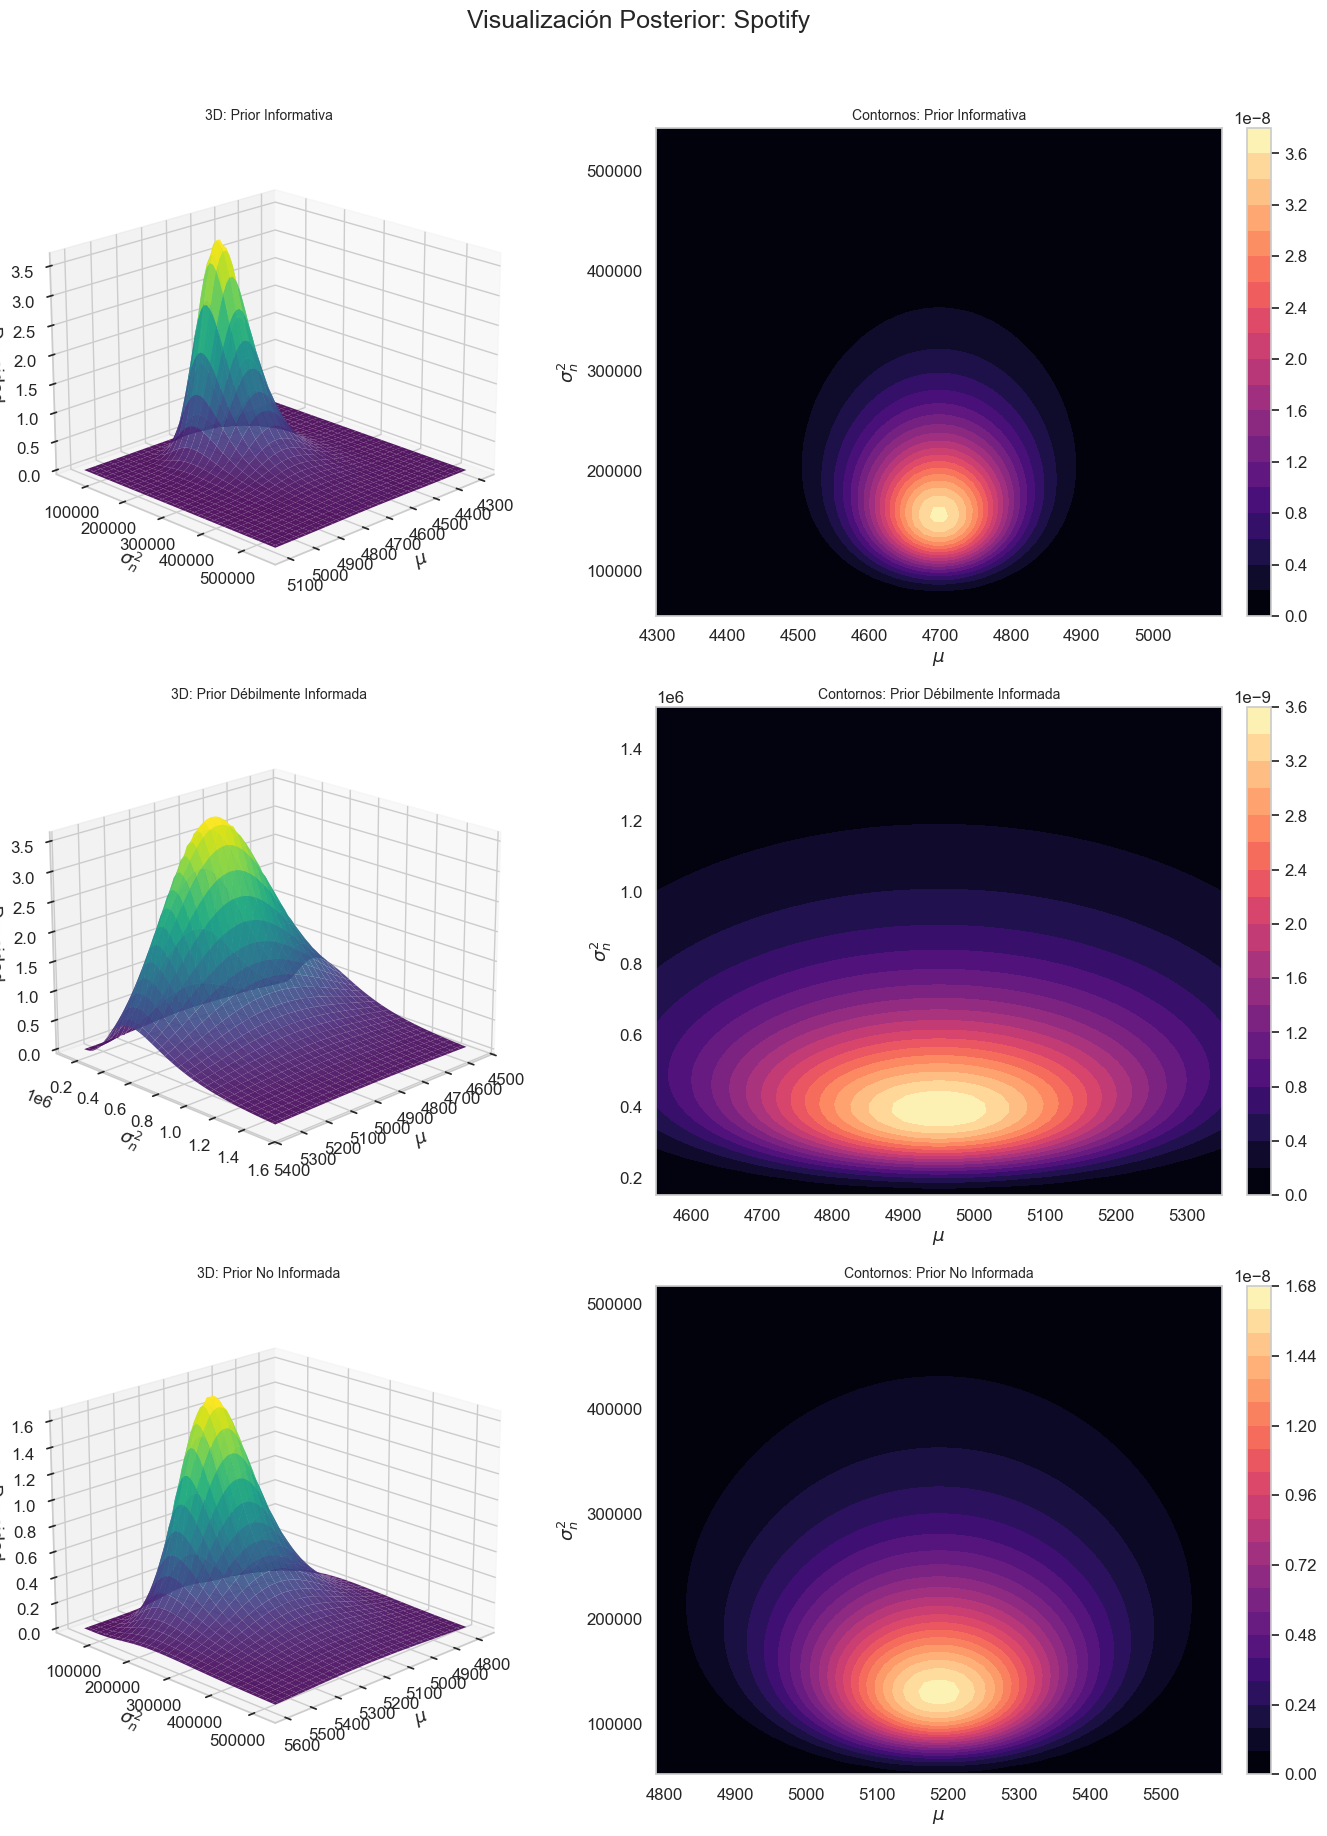

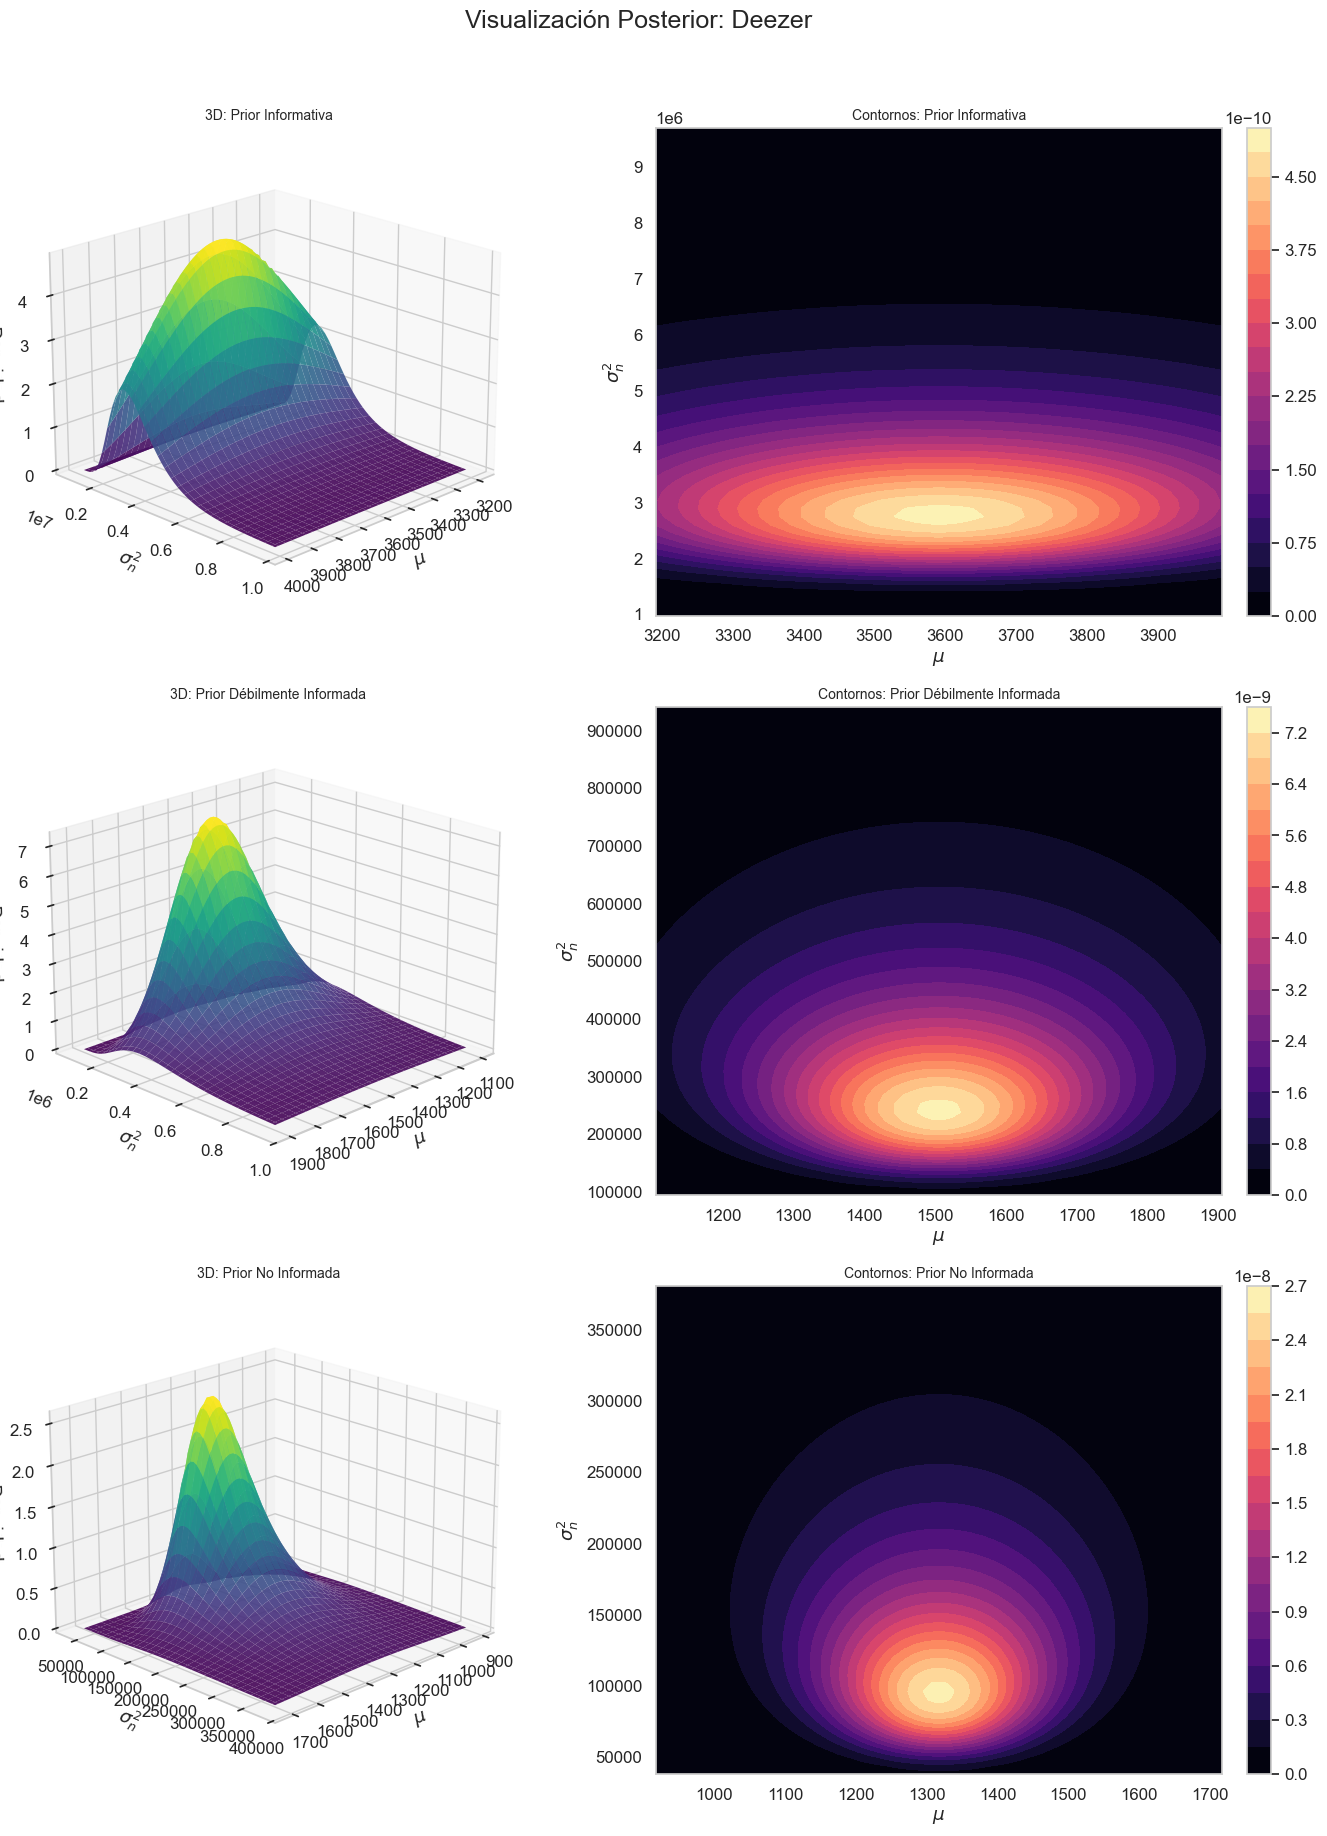

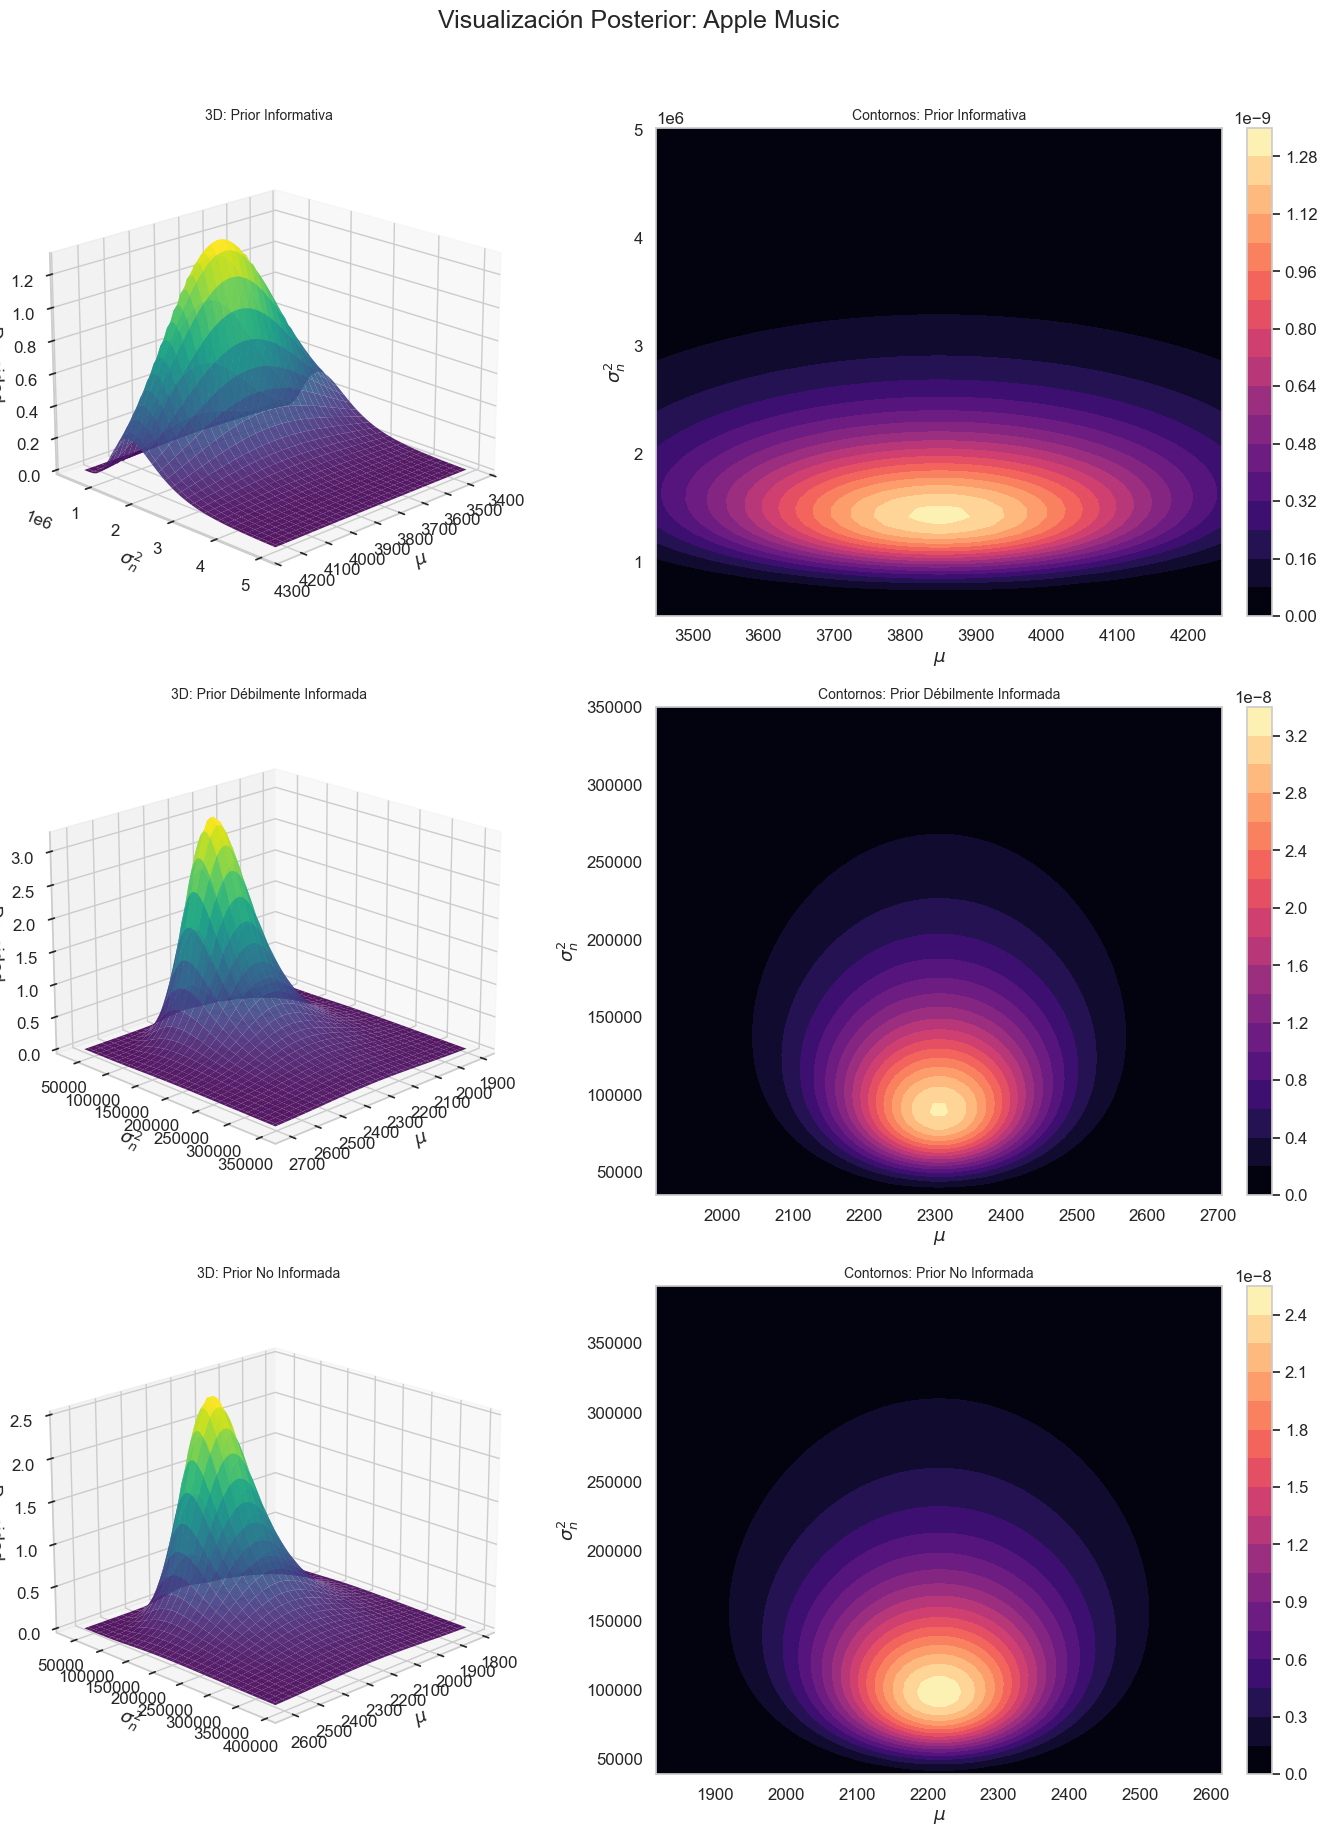

In [70]:
for pl_name in data_platforms.keys():
    fig = plt.figure(figsize=(14, 18))
    plt.suptitle(f"Visualización Posterior: {pl_name}", fontsize=18, y=1.02)
    
    for idx, pr_name in enumerate(norm_priors_config.keys()):
        vals = data_platforms[pl_name]
        mu0, k0, v0, s20 = norm_priors_config[pr_name]
        mun, kn, vn, s2n = nig_post(vals, mu0, k0, v0, s20)
        
        mu_grid = np.linspace(mun - 400, mun + 400, 60)
        s2_grid = np.linspace(s2n * 0.3, s2n * 3.0, 60)
        M, S2 = np.meshgrid(mu_grid, s2_grid)
        Z = norm.pdf(M, mun, np.sqrt(S2/kn)) * invgamma.pdf(S2, vn/2, scale=(vn*s2n)/2)
        
        # 3D Plot
        ax = fig.add_subplot(3, 2, 2*idx + 1, projection='3d')
        ax.plot_surface(M, S2, Z, cmap=cm.viridis, edgecolor='none', alpha=0.9)
        ax.set_title(f"3D: {pr_name}", fontsize=10)
        ax.set_xlabel(r'$\mu$')
        ax.set_ylabel(r'$\sigma^2_n$')
        ax.set_zlabel('Densidad')
        ax.view_init(elev=20, azim=45)
        
        # Contour Plot
        ax2 = fig.add_subplot(3, 2, 2*idx + 2)
        cp = ax2.contourf(M, S2, Z, 20, cmap='magma')
        ax2.set_title(f"Contornos: {pr_name}", fontsize=10)
        ax2.set_xlabel(r'$\mu$')
        ax2.set_ylabel(r'$\sigma^2_n$')
        plt.colorbar(cp, ax=ax2, fraction=0.046, pad=0.04)
        
    plt.tight_layout()
    plt.show()

### Pregunta 5: Compare las medias posteriores entre plataformas en los tres escenarios.

**Análisis Comparativo Extendido:**

Al observar las medias posteriores ($\mu_n$) en los tres escenarios, extraemos conclusiones críticas sobre la robustez de los datos:

1. **Estabilidad Invariante de la Jerarquía**: El orden de desempeño ($Spotify > YouTube > Apple\;Music > Deezer$) se mantiene **constante en todos los escenarios**. Esto indica que la señal de los datos es lo suficientemente fuerte para superar cualquier sesgo introducido por las priors, otorgando una alta fiabilidad a la clasificación de plataformas.

2. **Fuerza de Atracción de la Prior Informativa**: 
   - **Spotify**: Su media de ~5187 (Escenario No Informado) sufre una disminución hacia ~4833 cuando se aplica la creencia previa de 4500. La prior actúa como un "lastre" que modera el optimismo de los datos observados.
   - **YouTube**: Por el contrario, su media de ~4249 es "tirada" hacia arriba hasta ~4274 por la misma prior de 4500. 
   - Este comportamiento ilustra perfectamente la mecánica bayesiana de actualización: la posterior es un compromiso ponderado entre lo que creíamos y lo que vimos.


### Pregunta 6: Analice cómo cambian las distribuciones posteriores cuando se modifica le nivel de información de la prior.

**Respuesta:** 
- **Prior Informativa (Creencia Fuerte):** Los picos de densidad son mucho más altos y estrechos. La incertidumbre sobre $\mu$ y $\sigma^2$ es mínima porque los datos confirman o se ajustan a una creencia previa con mucha fuerza (parámetros $\kappa_0$ y $\nu_0$ altos).
- **Prior No Informada (Dominio de Datos):** Las distribuciones son más anchas y la densidad máxima es menor. Aquí, la posterior refleja casi exclusivamente la variabilidad observada en los 8 días de datos, permitiendo que la incertidumbre natural de la muestra se manifieste plenamente.

### Pregunta 7: Discuta cuál plataforma parece tener mayor potencial de reproducciones según los resultados obtenidos.

**Respuesta:** 
**Spotify** es, sin duda, la plataforma con mayor potencial. No solo presenta la media posterior más alta, sino que su distribución de probabilidad está desplazada significativamente a la derecha de las demás. Incluso en el escenario más conservador, su desempeño supera con creces al segundo lugar (YouTube). Esto sugiere una base de usuarios más activa o una mejor afinidad del género experimental con esta plataforma.

### Pregunta 8: Comparación gráfica o conceptual de las distribuciones posteriores entre plataformas y escenarios.

**Análisis Conceptual:**

Al comparar las plataformas, observamos una relación directa entre el volumen de reproducciones y la variabilidad. **Spotify** muestra una campana más ancha en términos absolutos, lo que indica que, aunque el potencial es alto, también hay fluctuaciones diarias significativas. En contraste, **Deezer** muestra una distribución muy compacta, lo que sugiere un comportamiento muy estable y predecible, aunque en niveles bajos.

Respecto a los escenarios, la **Prior Informativa** actúa como un ancla gravitacional. Si la prior dice que la media es 4500, platforms como Spotify ven su media posterior reducida (de ~5200 a ~4800), mientras que plataformas como Deezer la ven aumentada. En los escenarios **No Informados**, las plataformas se "liberan" de este ancla y muestran su verdadera naturaleza estadística basada en los datos recolectados. Esto demuestra que para decisiones de nicho, una prior muy fuerte puede oscurecer la realidad específica de una plataforma.

### Pregunta 9: Si la empresa solo puede invertir en dos plataformas para promoción inicial, ¿cuáles elegiría y por qué?

**Respuesta:** 
Elegiríamos **Spotify** y **YouTube**.
- **Spotify**: Por su volumen dominante y la alta tasa de descubrimiento que sugieren los datos.
- **YouTube**: Porque es la segunda plataforma en volumen y ofrece una naturaleza visual/social que complementa bien el lanzamiento de un artista nuevo, permitiendo una mayor viralización que servicios puramente de audio como Apple Music o Deezer.

### Pregunta 10: Finalmente, discuta si la elección de la prior cambia significativamente la decisión estratégica del lanzamiento.

**Respuesta:** 
En este caso específico, **no cambia la decisión fundamental**. Aunque la prior informativa desplaza los números, la diferencia en el desempeño entre Spotify/YouTube y las demás es tan grande que los datos terminan imponiendo la misma jerarquía estratégica. Sin embargo, en términos de **proyección presupuestaria**, la elección de la prior sí es crítica: usar una prior informativa sesgada hacia 4500 llevaría a subestimar el éxito en Spotify y sobreestimar en Deezer, lo cual podría causar errores en la asignación de recursos monetarios.